# Import

In [7]:
import numpy as np
from scipy.stats import norm
import utils

import pandas as pd

import matplotlib.pyplot as plt
import plotly.graph_objs as go
from ipywidgets import widgets, HBox, VBox, Output

from importlib import reload

# Sanity check

## Parameters

In [8]:
params_glob = {'sigma':0.2, 'rate': 0.15, 'T': 1, 'strike': 100, 'S0': 100}
params_LP = {'a0': 1, 'a1': 30, 'a2': 10, 'ksi': 3, 'X0': 10**6, 'Y0': 10**3, 'gamma': 10**(-8), 'fees_coeff': 0.05}
params_grid = {'n_paths': 10000, 'n_steps': 500}

In [9]:
params = {**params_glob, **params_grid}
option_type = 'call'

# Define payoff function
if option_type == 'call':
    g = lambda X, K : np.maximum(X-K, 0)
elif option_type == 'put':
    g = lambda X, K : np.maximum(K-X, 0)
else:
    raise ValueError

## Generate Paths

In [10]:
BM_type = 'geometric'  # 'geometric' or 'arithmetic'

sanityCheck_path_generator_obj = utils.Solver(**{**params_glob, **params_grid, **params_LP})
S = sanityCheck_path_generator_obj.external_mid_price_paths(BM_type=BM_type)

## European Option

In [11]:
print("Brownian Motion type:", BM_type, end='\n\n')

# European Call Option price by Monte Carlo
Call_Option_MC = np.mean(np.exp(-params['rate']*params['T'])*np.maximum(S[:,-1]-params['strike'], 0))
Put_Option_MC = np.mean(np.exp(-params['rate']*params['T'])*np.maximum(params['strike']-S[:,-1], 0))

IC_Call_Option_MC = np.array([-1.96,1.96])*np.sqrt(np.var(np.exp(-params['rate']*params['T'])*np.maximum(S[:,-1]-params['strike'], 0))/params['n_steps'])
IC_Put_Option_MC = np.array([-1.96,1.96])*np.sqrt(np.var(np.exp(-params['rate']*params['T'])*np.maximum(params['strike']-S[:,-1], 0))/params['n_steps'])

print(f"EU Call option price by Monte Carlo: {round(Call_Option_MC,2)} and confidence interval is {round(float(Call_Option_MC+IC_Call_Option_MC[0]),2),round(float(Call_Option_MC+IC_Call_Option_MC[1]),2)}")
print(f"EU Put option price by Monte Carlo: {round(Put_Option_MC,2)} and confidence interval is {round(float(Put_Option_MC+IC_Put_Option_MC[0]),2),round(float(Put_Option_MC+IC_Put_Option_MC[1]),2)}", end='\n\n')

# Exact solution
if BM_type == 'arithmetic':
    v = params['sigma'] * np.sqrt(params['T'])
    m = params['S0']
    d = (m-params['strike'])/v

    Call_Exact = np.exp(-params['rate']*params['T'])*((m-params['strike'])*norm.cdf(d) + v*norm.pdf(d))
    Put_Exact = np.exp(-params['rate']*params['T'])*((params['strike']-m)*norm.cdf(-d) + v*norm.pdf(d))

elif BM_type == 'geometric':
    d_plus = (np.log(params['S0']/params['strike']) + (params['rate'] + 0.5*params['sigma']**2)*params['T']) * (1/(params['sigma']*np.sqrt(params['T'])))
    d_minus = d_plus - params['sigma']*np.sqrt(params['T'])

    Call_Exact = params['S0']*norm.cdf(d_plus) - params['strike']*np.exp(-params['rate']*params['T'])*norm.cdf(d_minus)
    Put_Exact = - params['S0']*norm.cdf(-d_plus) + params['strike']*np.exp(-params['rate']*params['T'])*norm.cdf(-d_minus)

print(f"EU Call option price by closed form formula: {Call_Exact}")
print(f"EU Put option price by closed form formula: {Put_Exact}")

Brownian Motion type: geometric

EU Call option price by Monte Carlo: 16.01 and confidence interval is (14.53, 17.49)
EU Put option price by Monte Carlo: 2.46 and confidence interval is (1.98, 2.95)

EU Call option price by closed form formula: 16.355968471303683
EU Put option price by closed form formula: 2.4267661138094674


## Amercian Option

In [12]:
res = sanityCheck_path_generator_obj.longstaff_schwartz(paths=S, deg=2, problem_type='call')

print(f'Price of US {option_type} option by Longstaff-Schwartz method: {res["V0"]}')
print(f"Proportion of paths stopped before maturity: {100-round(np.sum(res['stopping_time'] == 500)/res['stopping_time'].shape[0],2)*100}%")

# Plot
fig, ax = plt.subplots(figsize=(20, 8))

nbr_path_plotted = 100
t_ = np.zeros(shape=(params['n_paths'], params['n_steps'] + 1))
t_[:,:] = np.linspace(0, params['T'], params['n_steps'] + 1)

for j in np.random.randint(0, high=params_grid['n_paths'], size=nbr_path_plotted, dtype=int):
        # Plot the paths before the optimal stopping time in green
        ax.plot(t_[j,:], S[j,:], 
                color='green', linestyle='--', linewidth=1, alpha=0.4)

        # Plot the paths after the optimal stopping time in red
        ax.plot(t_[j, int(res['stopping_time'][j])], S[j, int(res['stopping_time'][j])], 
                color='red', linestyle='--', marker='o', linewidth=1, markersize=3, alpha=1)

ax.set_xlim(left=0, right=params['T']+10**(-2))
ax.hlines(y=params['strike'], xmin=0, xmax=params['T'], color='black', linestyle='--', linewidth=0.8, label='Strike price')

# Add title and labels
ax.set_title(f'Stopping time of diffusion process for {option_type}')
ax.set_xlabel('Time')
ax.set_ylabel('Stock price')

# Show the plot
plt.show()

ValueError: problem_type must be either 'call_option', 'put_option', or 'amm'.

Price of US call option by Longstaff-Schwartz method: 16.11053959427154
Proportion of paths stopped before maturity: 30.0%


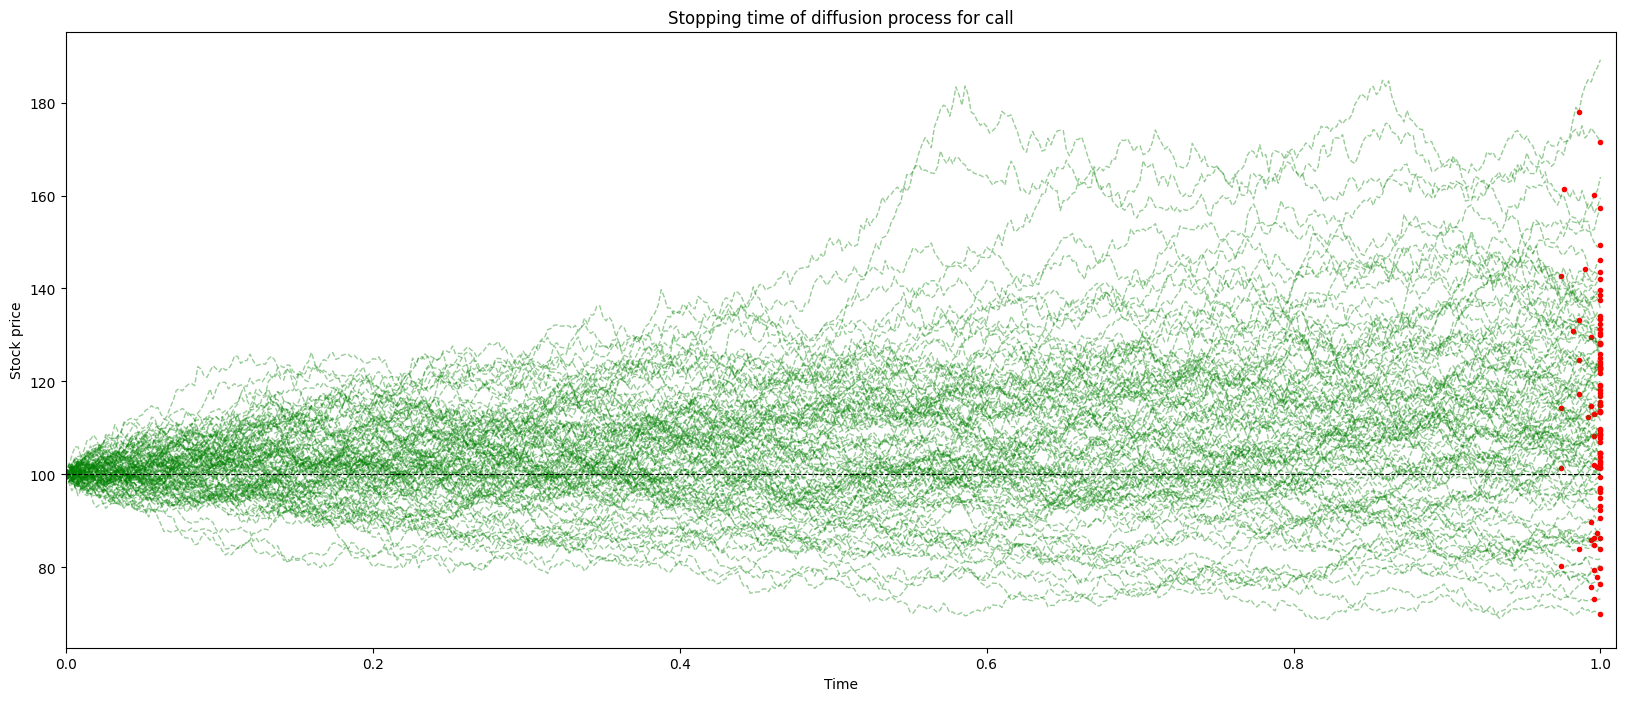

In [13]:
### M1 Philippe's code 

def american_option_longstaff_schwartz(S0, K, T, r, sigma, N, M, p, option_type='call'):
    """
    S0: Initial price of the underlying asset  
    K: Strike price  
    T: Maturity (in years)  
    r: Risk-free interest rate  
    sigma: Volatility of the underlying asset  
    N: Number of time steps  
    M: Number of Monte Carlo simulations  
    p: degree of the polynomial regression
    option_type: Option type ('call' or 'put')  
    return: Option price  
    """
    # Parameters
    dt = T / N  # time interval
    discount_factor = np.exp(-r * dt)  # factor to discount to the present

    # Monte-Carlo simulation
    np.random.seed(45)  # random results
    W = np.random.normal(0, 1, (M, N))  # gaussian noise
    S = np.zeros((M, N + 1))
    S[:, 0] = S0
    for t in range(1, N + 1):
       S[:, t] = S[:, t - 1] * np.exp((r - 0.5 * sigma**2) * dt + sigma * np.sqrt(dt) * W[:, t - 1])
            
    # Initialisation of Snell's envelope 
    Z = np.maximum(S[:, -1] - K, 0) if option_type == 'call' else np.maximum(K - S[:, -1], 0)
    
    tau_matrix = np.zeros_like(S)
    tau_matrix[:, -1] = 1


    # Longstaff-Schwartz
    for t in range(N - 1, 0, -1):
        itm = np.where(Z > 0)[0]  # In-the-money, we only keep positive pay-offs 
        if len(itm) == 0:
            continue

        # Regression of conditional expectation 
        X = S[itm, t]
        Y = Z[itm] * discount_factor # We discount to the present
        coeffs = np.polyfit(X, Y, p)  # polynomial of degree p
        continuation_values = np.polyval(coeffs, X) # Provides the value of the polynomial regression of the discounted conditional expectations

        # Calculation of immediate gains and make an optimal decision
        immediate_exercise = np.maximum(S[itm, t] - K, 0) if option_type == 'call' else np.maximum(K - S[itm, t], 0)
        Z[itm] = np.maximum(immediate_exercise, continuation_values) # induction to determine Snell's envelope

        stop_here = immediate_exercise >= continuation_values
        tau_matrix[itm, t] = stop_here.astype(int)
        

    # Option price at t = 0
    option_price = np.mean(Z) * np.exp(-r * dt)
    stopping_time = np.argmax(tau_matrix, axis=1)

    return {'V0':option_price, 'tau_matrix':tau_matrix, 'stopping_time':stopping_time}

# Input parameters
S0 = params['S0']         # Initial price of the underlying asset
K = params['strike']          # Strike price
T = params['T']          # Maturity (1 year)
r = params['rate']        # Risk-free interest rate (5%)
sigma = params['sigma']      # Volatility (20%)
N = params['n_steps']           # Number of time steps
M = params['n_paths']        # Number of Monte Carlo simulations
p = 2           # 7-order regression because p>7 provide an over-fit regression

res = american_option_longstaff_schwartz(S0, K, T, r, sigma, N, M, p, option_type)

print(f'Price of US {option_type} option by Longstaff-Schwartz method: {res["V0"]}')
print(f"Proportion of paths stopped before maturity: {100-round(np.sum(res['stopping_time'] == 500)/res['stopping_time'].shape[0],2)*100}%")

# Plot
fig, ax = plt.subplots(figsize=(20, 8))

nbr_path_plotted = 100
t_ = np.zeros(shape=(params['n_paths'], params['n_steps'] + 1))
t_[:,:] = np.linspace(0, params['T'], params['n_steps'] + 1)

for j in np.random.randint(0, high=params_grid['n_paths'], size=nbr_path_plotted, dtype=int):
        # Plot the paths before the optimal stopping time in green
        ax.plot(t_[j,:], S[j,:], 
                color='green', linestyle='--', linewidth=1, alpha=0.4)

        # Plot the paths after the optimal stopping time in red
        ax.plot(t_[j, int(res['stopping_time'][j])], S[j, int(res['stopping_time'][j])], 
                color='red', linestyle='--', marker='o', linewidth=1, markersize=3, alpha=1)

ax.set_xlim(left=0, right=params['T']+10**(-2))
ax.hlines(y=params['strike'], xmin=0, xmax=params['T'], color='black', linestyle='--', linewidth=0.8, label='Strike price')

# Add title and labels
ax.set_title(f'Stopping time of diffusion process for {option_type}')
ax.set_xlabel('Time')
ax.set_ylabel('Stock price')

# Show the plot
plt.show()

## LS Paper

In [14]:
# Example in the paper of Longstaff-Scwhartz

LS_solver_obj = utils.Solver(**{**{'sigma': 0.2, 'rate': 0.06, 'T': 3, 'strike': 1.1, 'S0': 1}, 
                                **{'n_paths': 8, 'n_steps': 3}, 
                                **params_LP})

S_LS_paper = np.array([[1, 1.09, 1.08, 1.34],
                        [1, 1.16, 1.26, 1.54],
                        [1, 1.22, 1.07, 1.03],
                        [1, 0.93, 0.97, 0.92],
                        [1, 1.11, 1.56, 1.52],
                        [1, 0.76, 0.77, 0.90],
                        [1, 0.92, 0.84, 1.01],
                        [1, 0.88, 1.22, 1.34]])

option_type = 'put'

# Define payoff function
if option_type == 'call':
    g = lambda X, K : np.maximum(X-K,0)
elif option_type == 'put':
    g = lambda X, K : np.maximum(K-X,0)
else:
    raise ValueError

res_LS = LS_solver_obj.longstaff_schwartz(paths=S_LS_paper, deg=2, problem_type='put')
print(f'Price of US {option_type} option by Longstaff-Schwartz method: {round(res_LS["V0"],4)} vs on LS paper: 0.1144')

ValueError: problem_type must be either 'call_option', 'put_option', or 'amm'.

# AMM Simulation Process

## Parameters

In [16]:
# Parameters
params_glob = {'sigma': 100, 'rate': 0, 'T': 1, 'strike': None, 'S0': 1*10**3}
params_LP = {'a0': 4 , 'a1': 8, 'a2': 0.04, 'ksi': 3, 'X0': 1*10**6, 'Y0': 1*10**3, 'gamma': 10**(-8), 'fees_coeff': 0.1}
params_grid = {'n_paths': 10_000, 'n_steps': 2000}

BM_type = 'arithmetic'  # 'geometric' or 'arithmetic'

## Longstaff-Scwhartz

In [17]:
# Create solver object in order to apply Longstaff-Schwartz method and Euler
amm_solver_obj = utils.Solver(**{**params_glob, **params_grid, **params_LP})

In [18]:
# Solving the AMM problem using Longstaff-Schwartz method
amm_solver_obj.amm_model(BM_type=BM_type)

amm_paths = amm_solver_obj.get_paths()['amm_model_0']
res_LS = amm_solver_obj.longstaff_schwartz(paths=amm_paths, deg=2, problem_type='amm')

# Prepare data for plotting
external_mid_price_S_LS = amm_solver_obj.get_paths()['external_mid_price_S']
asset_Z = amm_solver_obj.get_paths()['asset_Z']
fees_R = amm_solver_obj.get_paths()['fees']

input_params = amm_solver_obj.get_params()

t_ = np.zeros(shape=(params_grid['n_paths'], params_grid['n_steps'] + 1))
t_[:,:] = np.linspace(0, params_glob['T'], params_grid['n_steps'] + 1)

value_function_LS = res_LS['V_matrix']

In [19]:
x = t_[np.arange(params_grid['n_paths']), res_LS['stopping_time']]       
y = external_mid_price_S_LS[np.arange(params_grid['n_paths']), res_LS['stopping_time']] #- asset_Z[np.arange(params_grid['n_paths']), res_LS['stopping_time']]
z = fees_R[np.arange(params_grid['n_paths']), res_LS['stopping_time']] 

# Plotting the results in 3D
fig = go.Figure(data=go.Scatter3d(
    x=x,       
    y=y,       
    z=z, 
    mode='markers',
    line=dict(color='blue'),
    marker=dict(size=1)
))

fig.update_layout(
    scene=dict(
        xaxis_title='Time',
        yaxis_title='S at exit time',
        zaxis_title='Fees at exit time',
        xaxis=dict(range=[0, params_glob['T']]),
    ),
    scene_camera=dict(
        eye=dict(x=1.5, y=1.5, z=1.5),
        center=dict(x=0, y=0, z=-0.2) 
    ),
    margin=dict(l=0, r=0, t=0, b=0)
)

params_text = (
    f"sigma: {input_params['sigma']}<br>"
    f"rate: {input_params['rate']}<br>"
    f"T: {input_params['T']}<br>"
    f"a0: {input_params['a0']}<br>"
    f"a1: {input_params['a1']}<br>"
    f"a2: {input_params['a2']}<br>"
    f"ksi: {input_params['ksi']}<br>"
    f"X0: {input_params['X0']}<br>"
    f"Y0: {input_params['Y0']}<br>"
    f"Initial local price: {input_params['X0']/input_params['Y0']}<br>"
)

fig.add_annotation(
    text=params_text,
    xref="paper", yref="paper",
    align="left",
    showarrow=False,
    x=0, y=0,                       
    font=dict(size=12),
    opacity=0.8
)

fig.show()

## Euler

In [20]:
res_euler = amm_solver_obj.euler(delta=input_params['T']/params_grid['n_steps'], h=10, scale_factor=0.8)
value_function_euler = res_euler['V_matrix']

In [22]:
t = 2*input_params['T']/3
dt = input_params['T']/params_grid['n_steps']

z = value_function_euler[int(t/dt), :, :]
jumps, space = np.meshgrid(res_euler['external_mid_price_S'], res_euler['jumps_grid'])

fig = go.Figure()

# Plot the entire surface as dots
fig.add_trace(go.Surface(
    x=jumps,
    y=space,
    z=z,
))

fig.update_layout(
    width=800,
    height=700,
    scene=dict(
        xaxis_title='Y',
        yaxis_title='S',
        zaxis_title='Value',
    ),
    scene_camera=dict(
    eye=dict(x=1.5, y=1.5, z=1.5),
    center=dict(x=0, y=0, z=-0.2) 
    ),
    title = f'Value Function of AMM Model by Euler Method at time t={round(t,3)}',
)

params_text = (
    f"sigma: {input_params['sigma']}<br>"
    f"rate: {input_params['rate']}<br>"
    f"T: {input_params['T']}<br>"
    f"a0: {input_params['a0']}<br>"
    f"a1: {input_params['a1']}<br>"
    f"a2: {input_params['a2']}<br>"
    f"ksi: {input_params['ksi']}<br>"
    f"X0: {input_params['X0']}<br>"
    f"Y0: {input_params['Y0']}<br>"
    f"Initial local price: {input_params['X0']/input_params['Y0']}<br>"
)

fig.add_annotation(
    text=params_text,
    xref="paper", yref="paper",
    align="left",
    showarrow=False,
    x=0, y=0,                       
    font=dict(size=12),
    opacity=0.8
)


## Longstaff-Schwartz vs Euler

In [32]:
t = 0.2*input_params['T']
dt = input_params['T']/params_grid['n_steps']

fig = go.Figure()

# Plot the entire surface as dots
z = value_function_euler[int(t/dt), :, :]
jumps, space = np.meshgrid(res_euler['external_mid_price_S'], res_euler['jumps_grid'])
fig.add_trace(go.Surface(
   x=jumps,
   y=space,
   z=z,
   opacity=0.55
))

# Add the LS line slice to the plot
df_ = pd.DataFrame({'external_mid_price_S':5*np.round(external_mid_price_S_LS[:, int(t/dt)]/5), 
                   'value_function':value_function_LS[:, int(t/dt)]})
groupby_df = df_.groupby('external_mid_price_S').mean().reset_index()
print(df_.groupby('external_mid_price_S').count().reset_index())
y = groupby_df['external_mid_price_S'].to_numpy()
z = groupby_df['value_function'].to_numpy()
fig.add_trace(go.Scatter3d(
    x=[input_params['Y0']] * len(external_mid_price_S_LS),
    y=y, #external_mid_price_S_LS[:, int(t/dt)],  # Use the external mid price at the specified time slice
    z=z, #value_function_LS[:, int(t/dt)],  # Use the value function at the specified time slice
    mode='markers',
    marker=dict(color='green', size=4),
    name='LS Line Slice'
))

# Update layout for the 3D plot
fig.update_layout(
    width=900,
    height=700,
    scene=dict(
        xaxis_title='Y',
        yaxis_title='S',
        zaxis_title='Value',
    ),
    scene_camera=dict(
    eye=dict(x=1.5, y=1.5, z=1.5),
    center=dict(x=0, y=0, z=-0.2) 
    ),
    title = f'Value Function of AMM Model by Euler Method at time t={round(t,3)}',
)

params_text = (
    f"sigma: {input_params['sigma']}<br>"
    f"rate: {input_params['rate']}<br>"
    f"T: {input_params['T']}<br>"
    f"a0: {input_params['a0']}<br>"
    f"a1: {input_params['a1']}<br>"
    f"a2: {input_params['a2']}<br>"
    f"ksi: {input_params['ksi']}<br>"
    f"X0: {input_params['X0']}<br>"
    f"Y0: {input_params['Y0']}<br>"
    f"Initial local price: {input_params['X0']/input_params['Y0']}<br>"
)

fig.add_annotation(
    text=params_text,
    xref="paper", yref="paper",
    align="left",
    showarrow=False,
    x=0, y=0,                       
    font=dict(size=12),
    opacity=0.8
)


    external_mid_price_S  value_function
0                  840.0               1
1                  845.0               1
2                  850.0               2
3                  855.0               1
4                  860.0               3
..                   ...             ...
59                1135.0               3
60                1140.0               4
61                1145.0               4
62                1150.0               2
63                1165.0               1

[64 rows x 2 columns]


In [33]:
df_.groupby('external_mid_price_S').count().reset_index()

,external_mid_price_S,value_function
0,840.0,1
1,845.0,1
2,850.0,2
3,855.0,1
4,860.0,3
...,...,...
59,1135.0,3
60,1140.0,4
61,1145.0,4
62,1150.0,2


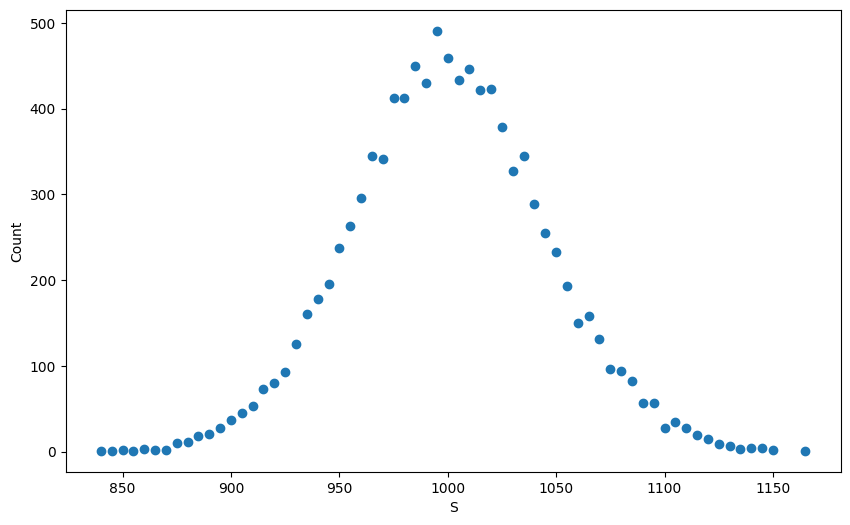

In [42]:
plt.figure(figsize=(10, 6))
plt.scatter(x=df_.groupby('external_mid_price_S').count().reset_index()['external_mid_price_S'], y=df_.groupby('external_mid_price_S').count().reset_index()['value_function'])
plt.xlabel('S')
plt.ylabel('Count')
plt.title('')
plt.show()

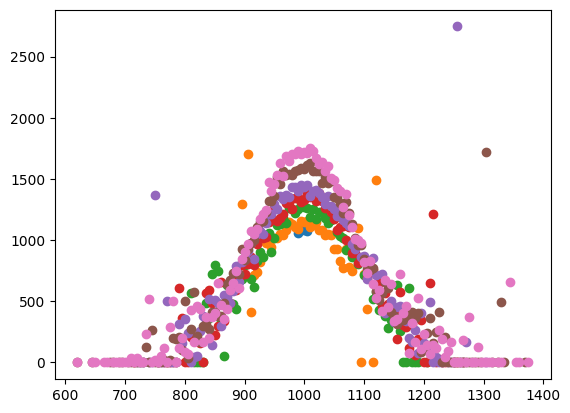

In [ ]:

for decimal in [0.001,0.1,0.3,0.5,0.7,0.9,0.99]:
    t = decimal*input_params['T']
    df_ = pd.DataFrame({'external_mid_price_S':5*np.round(external_mid_price_S_LS[:, int(t/dt)]/5), 
                    'value_function':value_function_LS[:, int(t/dt)]})
    groupby_df = df_.groupby('external_mid_price_S').mean().reset_index()
    y = groupby_df['external_mid_price_S'].to_numpy()
    z = groupby_df['value_function'].to_numpy()
    plt.scatter(y, z,)